# Pose estimation - Application

In this notebook, we will use a pose estimation model to analyze the **Sit-to-Stand (STS) Test**.

## STS Test

The STS test is one of the simplest and most informative functional tasks in human movement. It captures essential components of mobility:
- lower-limb strength
- balance and postural control
- coordination
- movement speed (vigor)

Clinically, STS performance is widely used to assess:
- aging-related decline
- musculoskeletal conditions (e.g., osteoarthritis)
- neurological impairments


## Dataset 
A recent paper 

>Boswell, M. A., Kidziński, Ł., Hicks, J. L., Uhlrich, S. D., Falisse, A., & Delp, S. L. (2023). Smartphone videos of the sit-to-stand test predict osteoarthritis and health outcomes in a nationwide study. NPJ digital medicine, 6(1), 32.

Demonstrated that simple smartphone videos collected at home can be used to extract meaningful biomechanical signals that relate to health status. The authors proposed a simple pipeline consisting of:
1. Record a short video of a person performing repeated sit-to-stand movements
2. Use pose estimation to extract body keypoints
3. Convert keypoints into kinematic signals
4. Relate those signals to clinical outcomes

The authors made some of this dataset available online, we will use this data in this notebook. 

<div style="text-align:center">
<img src="images/Sit2Stand.jpg" alt="plot" width="800" />
</div>


In the dataset, there are videos of healthy older adults, and older adults with osteoarthritis. Further, the data includes measures of overall physical and mental health. 

As you can see, the videos show participants performing the STS test. Instead of working directly with the videos, we will use pose estimation to extract information from the videos that can provide information about the performance of the STS test. 

In the paper, the authors extracted a measure of trunk inclination; however, this measure is influenced by the camera position, so correct trunk angle estimation likely needs to know the subject orientation or reconstruct the 3d posture. Is not clear if the authors knew the true camera orientation when estimating the angle. 

In this notebook, we will work with another variable, which measures overall feeling of physical health in a scale of 1 to 5, as follows:
1. Poor
2. Fair
3. Good
4. Very good
5. Excellent

Participants were asked to provide an assessment of their overall physical health using this scale. We will use a binary representation of this scale, with scores 1, 2, and 3 assigned to class *unhealthy* and scores 4 and 5 to class *healthy*. 

The overall objective of this notebook is to use data derived from the video to predict if the subjects consider themselves *healthy* or *unhealthy* using out scale.

In this project, we will use a simpler measure, corresponding to the vertical displacement of the body. This signal will allow us to identify when the person stands and sit, as well as obtain multiple measures related to the vigor of the movement and the consistency, these factors are likely to be affected by musculoskeletal disorders, such as osteoarthritis.



### What you will learn in this notebook

By the end of this notebook, you will be able to:
1.	Extract a movement signal from pose data
2.	Detect sit-to-stand cycles
3.	Identify movement phases (start/end of ascent)
4.	Compute kinematic features such as:
    - speed
	- duration
	- amplitude
5.	Build features that can be used for machine learning models


## Part A - Pose Estimation
We need to analyze one video first and decide what is the best way to extract features

In [1]:
import numpy as np
import pandas as pd
import os
import matplotlib.pyplot as plt
from ultralytics import YOLO
import cv2
import numpy as np
import matplotlib.pyplot as plt
import torch

from ipywidgets import IntSlider, Play, HBox, VBox, jslink, interactive_output
from IPython.display import display


edges = [
    (5, 7), (7, 9),     # left arm
    (6, 8), (8, 10),    # right arm
    (5, 6),             # shoulders
    (5, 11), (6, 12),   # torso sides
    (11, 12),           # hips
    (11, 13), (13, 15), # left leg
    (12, 14), (14, 16), # right leg
    (0, 5), (0, 6)      # head to shoulders
]

#keypoint labels for COCO dataset
keypoint_labels = {
    0: 'nose',
    1: 'left_eye',
    2: 'right_eye',
    3: 'left_ear',
    4: 'right_ear',
    5: 'left_shoulder',
    6: 'right_shoulder',
    7: 'left_elbow',
    8: 'right_elbow',
    9: 'left_wrist',
    10: 'right_wrist',
    11: 'left_hip',
    12: 'right_hip',
    13: 'left_knee',
    14: 'right_knee',
    15: 'left_ankle',
    16: 'right_ankle'
}   

In [2]:
video_path = "data/sit2stand/videos_sit2stand_valid/4RF13po6.mp4"#/0nUjlcd7.mp4"
model = YOLO("models/yolo26s-pose.pt")  # COCO 17-keypoint pose model

#YOLO pose can run the models directly from the video!
# Run pose tracking
results = model.track(
    source=video_path,
    stream=True,
    tracker="bytetrack.yaml",
    persist=True,
    verbose=False,
    device = 'mps' if torch.backends.mps.is_available() else 'cpu'
)

# #if kernel dies, then use this method:
# results = model.predict(
#     source=video_path,
#     verbose=False,
#     device = 'cpu'
# )

#get info from the video to make the plot
cap = cv2.VideoCapture(video_path)
w = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
h = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
fps = cap.get(cv2.CAP_PROP_FPS)
cap.release()



#extracting keypoints from the results
frame_ids = []
pose_seq = []  # (num_frames_detected, 17, 2)
results_list = list(results)
for i, r in enumerate(results_list):
    if r.keypoints is None or len(r.keypoints.xy) == 0:
        continue

    # Pick the highest-confidence person in frame
    kpts = r.keypoints.xy.cpu().numpy()  # (n_people, 17, 2)
    conf = r.boxes.conf.cpu().numpy() if r.boxes is not None else np.ones(len(kpts))
    person_idx = int(np.argmax(conf))

    frame_ids.append(i)
    pose_seq.append(kpts[person_idx])

#plotting the keypoints and skeleton connections for a given frame index
def plot_pose_frame(frame_idx):
    kpts_frame = pose_seq[frame_idx]

    fig, ax = plt.subplots(figsize=(5, 5))
    ax.scatter(kpts_frame[:, 0], kpts_frame[:, 1], s=30, c="red")

    # Draw skeleton connections
    for a, b in edges:
        ax.plot(
            [kpts_frame[a, 0], kpts_frame[b, 0]],
            [kpts_frame[a, 1], kpts_frame[b, 1]],
            color="cyan",
            linewidth=2
        )

    ax.set_xlim(0, w)
    ax.set_ylim(h, 0)  # image coordinates
    ax.set_aspect("equal", adjustable="box")
    ax.set_title(f"Pose keypoints - frame {frame_ids[frame_idx]} (index {frame_idx})")
    ax.set_xlabel("X (pixels)")
    ax.set_ylabel("Y (pixels)")
    ax.grid(alpha=0.2)
    plt.show()

slider = IntSlider(value=0, min=0, max=len(pose_seq) - 1, step=1, description="Frame")
play = Play(value=0, min=0, max=len(pose_seq) - 1, step=1, interval=80, description="Press play")
jslink((play, "value"), (slider, "value"))

ui = HBox([play, slider])
out = interactive_output(plot_pose_frame, {"frame_idx": slider})
display(VBox([ui, out]))


## Part A.1 Signal Extraction

We need to decide the best way to quantify the movement during the STS test.  

From the pose estimation results and based on the instructions of the test, the subjects leaves the feet on the ground while the sit to stand movement is performed, so, we can use the vertical distance between the torso Center of Mass (COM) and the ankles. 

The Torso COM is the average of the shoulders and hips keypoints, and can be computed as 

```Python
    torso_COM = np.mean(pose[[5,6,11,12],:], axis=0)
```

the center of the ankles can be computed as 

```Python
    ankles_center = np.mean(pose[15:17, :], axis=0)
```

Remember also to smooth the signal!


Text(0.5, 1.0, 'Vertical movement of the person over time')

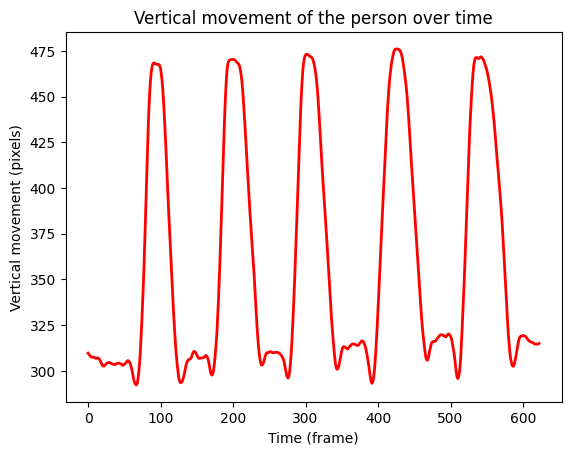

In [4]:
from scipy.signal import savgol_filter, find_peaks, butter, filtfilt,detrend

vertical_movement_frames = []
for pose in pose_seq:


    torso_COM = np.mean(pose[[5,6,11,12], :], axis=0)  # (n_people, 2)
    ankles_center = np.mean(pose[15:17, :], axis=0)  # (n_people, 2)

    vertical_movement = np.abs(torso_COM[1] - ankles_center[1])  # Use distance between shoulders and ankles as a proxy for vertical movement
    vertical_movement_frames.append(vertical_movement)


y_smooth = savgol_filter(vertical_movement_frames, window_length=11, polyorder=3, mode='nearest', deriv=0)  # Smooth the signal to reduce noise

plt.plot(np.array(frame_ids),y_smooth, color='red', linewidth=2)
# Invert y-axis to match image coordinates
plt.xlabel("Time (frame)")
plt.ylabel("Vertical movement (pixels)")
plt.title("Vertical movement of the person over time")

This is great! We can see how the distance between the ankles and the torso COM increases, indicating the person is standing, then decreases, indicating the person is sitting down. 

However, we have a **BIG problem.** Can you guess what the problem is? 

This signal depends on the distance from the subject to the camera (larger when the subject is closer) and the image resolution. Thus, we need to normalize the signal, so that is not influenced by those factors.

## Part A.2 Signal Normalization

In videos, we typically don't have true measures that help us normalize our data. Thus, we usually normalize the data based on some anatomical distance that allow us to compare between videos. 

In this case, a potential normalization factor is the subject height when standing. By normalizing by the subject height, we remove (partially) the influence of camera distance and image resolution.

We can now recompute the signal using a normalization factor

Text(0.5, 1.0, 'Vertical movement of the person over time')

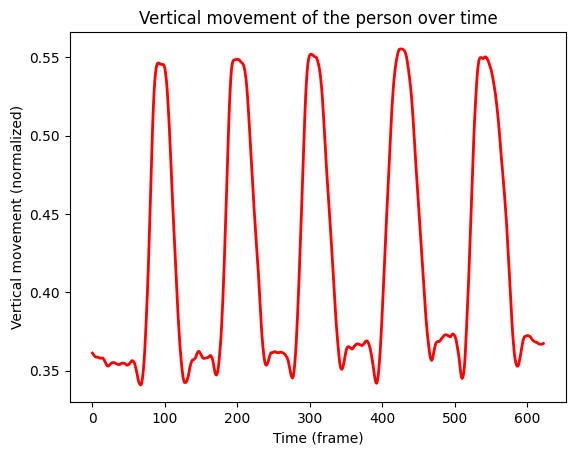

In [5]:
boxes_height = []
for i, r in enumerate(results_list):
    box_height = r.boxes.xywh.cpu().numpy()[:, 3][0] if r.boxes is not None else 0
    boxes_height.append(box_height)

y_smooth_normalized = y_smooth/np.max(boxes_height) if np.max(boxes_height) != 0 else y_smooth
plt.plot(np.array(frame_ids),y_smooth_normalized, color='red', linewidth=2)
# Invert y-axis to match image coordinates
plt.xlabel("Time (frame)")
plt.ylabel("Vertical movement (normalized)")
plt.title("Vertical movement of the person over time")

## Part A.3 Detecting Peaks

Now that we have the signal of interest, we can use it do detect when the person performed the STS test and how many times the test was performed, this can be achieved using a peak finder algorithm. As we have done before.

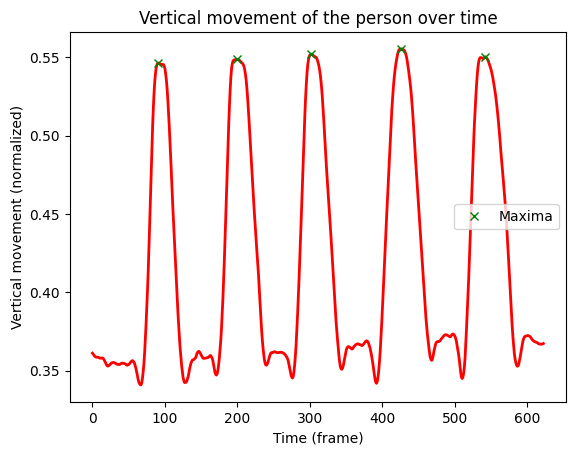

In [6]:
min_dist=fps # Minimum distance between peaks (e.g., 0.5 seconds)
prominence=0.05   
# Standing = local maxima
maxima_position, _ = find_peaks(y_smooth_normalized, distance=min_dist, prominence=0.25*(np.max(y_smooth_normalized)- np.min(y_smooth_normalized)))


plt.plot(np.array(frame_ids), y_smooth_normalized, color='red', linewidth=2)
plt.plot(np.array(frame_ids)[maxima_position], y_smooth_normalized[maxima_position], "x", label="Maxima", color="green")
plt.xlabel("Time (frame)")
plt.ylabel("Vertical movement (normalized)")
plt.title("Vertical movement of the person over time")
plt.legend()
plt.show()

Another important aspect of the movement is the movement speed, which will tell us to fast the person stands-up and sits-down. The velocity can be easily computed with a Savitzky–Golay filter 

Text(0.5, 1.0, 'Vertical velocity of the person over time')

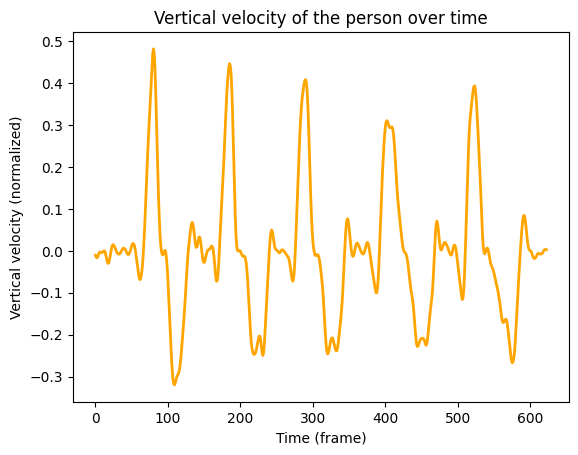

In [7]:
velocity_normalized = savgol_filter(y_smooth_normalized, window_length=11, polyorder=3, mode='nearest', deriv=1)*fps  # Compute velocity (first derivative)
plt.plot(np.array(frame_ids), velocity_normalized, color='orange', linewidth=2)
plt.xlabel("Time (frame)")
plt.ylabel("Vertical velocity (normalized)")
plt.title("Vertical velocity of the person over time")

Peaks in the velocity signal will tell us the maximum speed in each direction

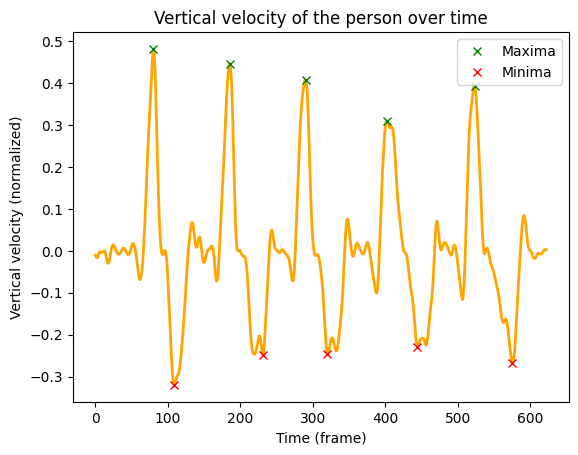

In [8]:
min_dist=fps # Minimum distance between peaks (e.g., 0.5 seconds)
prominence=0.05   
# Standing = local maxima
maxima_velocity, _ = find_peaks(velocity_normalized, distance=min_dist, prominence=0.25*(np.max(velocity_normalized)- np.min(velocity_normalized)))
minima_velocity, _ = find_peaks(-velocity_normalized, distance=min_dist, prominence=0.25*(np.max(velocity_normalized)- np.min(velocity_normalized))) 

plt.plot(np.array(frame_ids), velocity_normalized, color='orange', linewidth=2)
plt.plot(np.array(frame_ids)[maxima_velocity], velocity_normalized[maxima_velocity], "x", label="Maxima", color="green")
plt.plot(np.array(frame_ids)[minima_velocity], velocity_normalized[minima_velocity], "x", label="Minima", color="red")
plt.xlabel("Time (frame)")
plt.ylabel("Vertical velocity (normalized)")
plt.title("Vertical velocity of the person over time")
plt.legend()


## Part A.4 Feature Extraction

Now, we need to define what features we want to extract from the movement. There are many options, and you should spend a good amount of time defining what are the best features for your problem. 

These features will then be used to train a classification algorithm to detect the presence of osteoarthritis.

Another potential approach is to normalize the data (say pick two or three full sit to stand cycles and normalize its duration) and train a convolutional neural network to detect the presence of osteoarthritis directly from the signal. However, this approach usually requires large datasets. 

In this notebook, we will use a few features, including:

- Cadence (number of completed movements over time)
- Average time between peaks in distance signal
- STD of time between peaks in the distance signal 
- Average Maximum standing velocity 
- STD Maximum standing velocity 
- Average Maximum sitting velocity 
- STD Maximum sitting velocity 
- Average time between Max standing and Max Sitting velocity
- STD of time between Max standing and Max Sitting velocity
- Average ratio between max standing and max sitting velocity
- STD ratio between max standing and max sitting velocity

In [9]:
# --- Feature extraction from normalized STS signals ---

# 1) Peaks in distance (standing positions)
dist_peaks, _ = find_peaks(
    y_smooth_normalized,
    distance=int(fps),
    prominence=0.25 * (np.max(y_smooth_normalized) - np.min(y_smooth_normalized))
)

# 2) Peaks in velocity (max ascent / max descent)
vel_max_peaks, _ = find_peaks(
    velocity_normalized,
    distance=int(fps),
    prominence=0.25 * (np.max(velocity_normalized) - np.min(velocity_normalized))
)
vel_min_peaks, _ = find_peaks(
    -velocity_normalized,
    distance=int(fps),
    prominence=0.25 * (np.max(velocity_normalized) - np.min(velocity_normalized))
)

# --- Time base ---
total_time_sec = len(y_smooth_normalized) / fps

# --- Cadence and peak-spacing features ---
time_between_dist_peaks = np.diff(dist_peaks) / fps if len(dist_peaks) > 1 else np.array([])

cadence_per_min = (len(dist_peaks) / total_time_sec) * 60 if total_time_sec > 0 else np.nan
avg_time_between_dist_peaks = np.mean(time_between_dist_peaks) if len(time_between_dist_peaks) else np.nan
std_time_between_dist_peaks = np.std(time_between_dist_peaks) if len(time_between_dist_peaks) else np.nan

# --- Velocity amplitude features ---
standing_vel_peaks = velocity_normalized[vel_max_peaks] if len(vel_max_peaks) else np.array([])
sitting_vel_peaks = np.abs(velocity_normalized[vel_min_peaks]) if len(vel_min_peaks) else np.array([])

avg_max_standing_velocity = np.mean(standing_vel_peaks) if len(standing_vel_peaks) else np.nan
std_max_standing_velocity = np.std(standing_vel_peaks) if len(standing_vel_peaks) else np.nan

avg_max_sitting_velocity = np.mean(sitting_vel_peaks) if len(sitting_vel_peaks) else np.nan
std_max_sitting_velocity = np.std(sitting_vel_peaks) if len(sitting_vel_peaks) else np.nan

# --- Time between max standing velocity and subsequent max sitting velocity ---
stand_to_sit_times = []
for s in vel_max_peaks:
    next_sit = vel_min_peaks[vel_min_peaks > s]
    if len(next_sit):
        stand_to_sit_times.append((next_sit[0] - s) / fps)

stand_to_sit_times = np.array(stand_to_sit_times)
avg_time_stand_to_sit_vel = np.mean(stand_to_sit_times) if len(stand_to_sit_times) else np.nan
std_time_stand_to_sit_vel = np.std(stand_to_sit_times) if len(stand_to_sit_times) else np.nan

# Final feature set
features = {
    "cadence_per_min": cadence_per_min,
    "avg_time_between_distance_peaks_s": avg_time_between_dist_peaks,
    "std_time_between_distance_peaks_s": std_time_between_dist_peaks,
    "avg_max_standing_velocity": avg_max_standing_velocity,
    "std_max_standing_velocity": std_max_standing_velocity,
    "avg_max_sitting_velocity": avg_max_sitting_velocity,
    "std_max_sitting_velocity": std_max_sitting_velocity,
    "avg_time_between_max_stand_and_sit_velocity_s": avg_time_stand_to_sit_vel,
    "std_time_between_max_stand_and_sit_velocity_s": std_time_stand_to_sit_vel,
}

features_df = pd.DataFrame([features])
features_df

,cadence_per_min,avg_time_between_distance_peaks_s,std_time_between_distance_peaks_s,avg_max_standing_velocity,std_max_standing_velocity,avg_max_sitting_velocity,std_max_sitting_velocity,avg_time_between_max_stand_and_sit_velocity_s,std_time_between_max_stand_and_sit_velocity_s
0,14.446228,3.758333,0.272208,0.408288,0.057684,0.262096,0.031415,1.326667,0.299926
